<font size="+2">Double Deep Q-Learning & Open AI Gym: Intro</font>

# The Open AI Lunar Lander environment

The [OpenAI Gym](https://gym.openai.com/) is a RL platform that provides standardized environments to test and benchmark RL algorithms using Python. It is also possible to extend the platform and register custom environments.

The [Lunar Lander](https://gym.openai.com/envs/LunarLander-v2) (LL) environment requires the agent to control its motion in two dimensions, based on a discrete action space and low-dimensional state observations that include position, orientation, and velocity. At each time step, the environment provides an observation of the new state and a positive or negative reward.  Each episode consists of up to 1,000 time steps. The following diagram shows selected frames from a successful landing after 250 episodes by the agent we will train:

<img src="../assets/lunar_lander.png" width="700">

More specifically, the agent observes eight aspects of the state, including six continuous and two discrete elements. Based on the observed elements, the agent knows its location, direction, speed of movement, and whether it has (partially) landed. However, it does not know where it should be moving using its available actions or observe the inner state of the environment in the sense of understanding the rules that govern its motion.

At each time step, the agent controls its motion using one of four discrete actions. It can do nothing (and continue on its current path), fire its main engine (to reduce downward motion), or steer to the left or right using the respective orientation engines. There are no fuel limitations.

The goal is to land the agent between two flags on a landing pad at coordinates (0, 0), but landing outside of the pad is possible. The agent accumulates rewards in the range of 100-140 for moving toward the pad, depending on the exact landing spot. However, moving away from the target negates the reward the agent would have gained by moving toward the pad. Ground contact by each leg adds ten points, and using the main engine costs -0.3 points.

An episode terminates if the agent lands or crashes, adding or subtracting 100 points, respectively, or after 1,000 time steps. Solving LL requires achieving a cumulative reward of at least 200 on average over 100 consecutive episodes.

# Deep Q-Learning

Deep Q learning estimates the value of the available actions for a given state using a deep neural network. It was introduced by Deep Mind's [Playing Atari with Deep Reinforcement Learning](https://www.cs.toronto.edu/~vmnih/docs/dqn.pdf) (2013), where RL agents learned to play games solely from pixel input.

The Deep Q-Learning algorithm approximates the action-value function q by learning a set of weights  of a multi-layered Deep Q Network (DQN) that maps states to actions so that $$q(s,a,\theta)\approx q^*(s,a)$$

The algorithm applies gradient descent to a loss function defined as the squared difference between the DQN's estimate of the target
$$y_i=\mathbb{E}[r+\gamma\max_{a^\prime}Q(s^\prime, a^\prime; \theta_{i−1}\mid s,a)]$$
and its estimate of the action-value of the current state-action pair  to learn the network parameters:

$$L_i(\theta_i)=\mathbb{E}\left[\left(\overbrace{\underbrace{y_i}_{\text{Q Target}}−\underbrace{Q(s, a; \theta)}_{\text{Current Prediction}}}^{\text{TD Error}}\right)^2 \right]$$

Both the target and the current estimate depend on the set of weights, underlining the distinction from supervised learning where targets are fixed prior to training.

## Extensions

Several innovations have improved the accuracy and convergence speed of deep Q-Learning, namely:
- **Experience replay** stores a history of state, action, reward, and next state transitions and randomly samples mini-batches from this experience to update the network weights at each time step before the agent selects an ε-greedy action. It increases sample efficiency, reduces the autocorrelation of samples, and limits the feedback due to the current weights producing training samples that can lead to local minima or divergence.
- **Slowly-changing target network** weakens the feedback loop from the current network parameters on the neural network weight updates. Also invented by by Deep Mind in [Human-level control through deep reinforcement learning](https://web.stanford.edu/class/psych209/Readings/MnihEtAlHassibis15NatureControlDeepRL.pdf) (2015), it use a slowly-changing target network that has the same architecture as the Q-network, but its weights are only updated periodically. The target network generates the predictions of the next state value used to update the Q-Networks estimate of the current state's value.
- **Double deep Q-learning** addresses the bias of deep Q-Learning to overestimate action values because it purposely samples the highest action value. This bias can negatively affect the learning process and the resulting policy if it does not apply uniformly , as shown by Hado van Hasselt in [Deep Reinforcement Learning with Double Q-learning](https://arxiv.org/abs/1509.06461) (2015). To decouple the estimation of action values from the selection of actions, Double Deep Q-Learning (DDQN) uses the weights, of one network to select the best action given the next state, and the weights of another network to provide the corresponding action value estimate.


# Imports & Settings

> See the notebook `04_q_learning_for_trading.ipynb` for instructions on upgrading TensorFlow to version 2.2, required by the code below..

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
%matplotlib inline
from time import time
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# OpenAI Gym
import gymnasium as gym

import matplotlib.pyplot as plt
import seaborn as sns

2025-10-04 13:04:25.744429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759583065.767409     504 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759583065.774484     504 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
sns.set_style("whitegrid", {"axes.grid": False})

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        try:
            # Enable memory growth to avoid allocating all GPU memory at once
            tf.config.experimental.set_memory_growth(g, True)
        except Exception:
            # may already be set or not supported on this platform
            pass
    print('Using GPU:', gpus)
else:
    print('Using CPU')

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Set random seeds to ensure results can be reproduced:

In [5]:
np.random.seed(42)
tf.random.set_seed(42)

## Result display helper functions

In [6]:
def format_time(t):
    m_, s = divmod(t, 60)
    h, m = divmod(m_, 60)
    return "{:02.0f}:{:02.0f}:{:02.0f}".format(h, m, s)

## Enable virtual display to run from docker container

This is only required if you run this on server that does not have a display.

In [7]:
# from pyvirtualdisplay import Display
# virtual_display = Display(visible=0, size=(1400, 900))
# virtual_display.start()

# Define DDQN Agent

We will use [TensorFlow](https://www.tensorflow.org/) to create our Double Deep Q-Network .

In [ ]:
# Running mean/std for observation normalization
class RunningMeanStd:
    """Keep a running estimate of mean and variance for normalization."""
    def __init__(self, epsilon=1e-4, shape=()):
        self.mean = np.zeros(shape, dtype=np.float64)
        self.var = np.ones(shape, dtype=np.float64)
        self.count = epsilon

    def _update_from_moments(self, batch_mean, batch_var, batch_count):
        delta = batch_mean - self.mean
        tot_count = self.count + batch_count
        new_mean = self.mean + delta * batch_count / tot_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        M2 = m_a + m_b + np.square(delta) * self.count * batch_count / tot_count
        self.mean = new_mean
        self.var = M2 / tot_count
        self.count = tot_count

    def update(self, x):
        x = np.array(x, dtype=np.float64)
        if x.ndim == 1:
            batch_mean = x
            batch_var = np.zeros_like(x)
            batch_count = 1
        else:
            batch_mean = np.mean(x, axis=0)
            batch_var = np.var(x, axis=0)
            batch_count = x.shape[0]
        self._update_from_moments(batch_mean, batch_var, batch_count)

    def normalize(self, x, clip=10.0):
        x = np.array(x, dtype=np.float64)
        return np.clip((x - self.mean) / (np.sqrt(self.var) + 1e-8), -clip, clip)

## Replay Buffer

In [ ]:
class Memory:
    def __init__(self, capacity, state_dims):
        self.capacity = capacity
        self.idx = 0

        self.state_memory = np.zeros(shape=(capacity, state_dims), dtype=np.float32)
        self.new_state_memory = np.zeros_like(self.state_memory)

        self.action_memory = np.zeros(capacity, dtype=np.int32)
        self.reward_memory = np.zeros_like(self.action_memory)
        self.done = np.zeros_like(self.action_memory)

    def store(self, state, action, reward, next_state, done):
        self.state_memory[self.idx, :] = state
        self.new_state_memory[self.idx, :] = next_state
        self.reward_memory[self.idx] = reward
        self.action_memory[self.idx] = action
        self.done[self.idx] = 1 - int(done)
        self.idx += 1

    def sample(self, batch_size):
        batch = np.random.choice(self.idx, batch_size, replace=False)

        states = self.state_memory[batch]
        next_states = self.new_state_memory[batch]
        rewards = self.reward_memory[batch]
        actions = self.action_memory[batch]
        done = self.done[batch]
        return states, actions, rewards, next_states, done


# TF-native replay buffer so sampling and training can run inside @tf.function
class TFMemory:
    def __init__(self, capacity, state_dims):
        self.capacity = int(capacity)
        self.state_dims = state_dims
        # write index (tracks number of stored items)
        self.idx = tf.Variable(0, dtype=tf.int32)

        device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
        with tf.device(device):
            self.state_memory = tf.Variable(tf.zeros([self.capacity, state_dims], dtype=tf.float32), trainable=False)
            self.new_state_memory = tf.Variable(tf.zeros([self.capacity, state_dims], dtype=tf.float32), trainable=False)
            self.action_memory = tf.Variable(tf.zeros([self.capacity], dtype=tf.int32), trainable=False)
            self.reward_memory = tf.Variable(tf.zeros([self.capacity], dtype=tf.float32), trainable=False)
            self.done = tf.Variable(tf.zeros([self.capacity], dtype=tf.float32), trainable=False)

    def store(self, state, action, reward, next_state, done):
        # store is called from Python training loop (eager mode)
        state_tf = tf.convert_to_tensor(state, dtype=tf.float32)
        next_state_tf = tf.convert_to_tensor(next_state, dtype=tf.float32)
        i = int(self.idx.numpy() % self.capacity)
        # assign into the TF buffers
        self.state_memory[i].assign(state_tf)
        self.new_state_memory[i].assign(next_state_tf)
        self.action_memory[i].assign(tf.cast(action, tf.int32))
        self.reward_memory[i].assign(tf.cast(reward, tf.float32))
        # store '1 - done' to match original logic
        self.done[i].assign(tf.cast(1 - int(done), tf.float32))
        self.idx.assign_add(1)

    @tf.function
    def sample(self, batch_size):
        # compute number of valid entries
        size = tf.minimum(self.idx, tf.constant(self.capacity, dtype=tf.int32))
        # draw random indices in range [0, size)
        idxs = tf.random.uniform([batch_size], minval=0, maxval=size, dtype=tf.int32)
        states = tf.gather(self.state_memory, idxs)
        next_states = tf.gather(self.new_state_memory, idxs)
        actions = tf.gather(self.action_memory, idxs)
        rewards = tf.gather(self.reward_memory, idxs)
        done = tf.gather(self.done, idxs)
        return states, actions, rewards, next_states, done

## Agent Class

In [ ]:
class DDQNAgent:
    """Double Deep Q-Network (DDQN) agent.

    This class implements a DDQN agent with experience replay and a separate
    target network. It contains methods to build the online/target networks,
    select actions using an epsilon-greedy policy, store transitions in a
    replay buffer, perform experience replay updates, and log/store results.

    Parameters (constructor):
    - ... (see notebook comments) ...
    - polyak: soft-update interpolation factor for target network updates (0..1).
    - n_step: number of steps for multi-step returns (n>=1). n=1 is standard 1-step TD.
    """
    def __init__(
        self,
        state_dim,
        num_actions,
        gamma,
        epsilon_start,
        epsilon_end,
        epsilon_decay_steps,
        epsilon_exponential_decay,
        learning_rate,
        architecture,
        l2_reg,
        replay_capacity,
        tau,
        batch_size,
        results_dir,
        use_tf_memory=True,
        log_every=10,
        polyak=0.995,
        n_step=1,
    ):
        # basic environment / agent dimensions
        self.state_dim = state_dim
        self.num_actions = num_actions

        # network and optimization hyperparameters
        self.architecture = architecture
        self.l2_reg = l2_reg
        self.learning_rate = learning_rate
        # replay buffer to store transitions for off-policy updates
        if use_tf_memory:
            self.experience = TFMemory(replay_capacity, state_dim)
            self.use_tf_memory = True
        else:
            self.experience = Memory(replay_capacity, state_dim)
            self.use_tf_memory = False
        self.gamma = gamma
        # tau here is used as a target update frequency (in steps)
        self.tau = tau
        # polyak factor for soft target updates (1 - polyak) is the step towards online weights
        self.polyak = polyak
        # n-step returns
        self.n_step = max(1, int(n_step))
        self._n_step_buffer = []  # per-episode buffer for n-step accumulation

        self.batch_size = batch_size
        self.idx = np.arange(batch_size, dtype=np.int32)  # helper index array

        # build online and target networks (same architecture). The target network
        # is used to provide stable targets when computing TD targets.
        self.online_network = self.build_model()
        # target network weights are not trainable (updated periodically)
        self.target_network = self.build_model(trainable=False)
        # optimizer used for updating online network weights
        self.optimizer = Adam(learning_rate=learning_rate)
        # loss function: use Huber for robustness to outliers
        self.loss_fn = tf.keras.losses.Huber()
        # synchronize target network with online network initially
        self.update_target()

        # epsilon-greedy exploration parameters
        self.epsilon = epsilon_start
        self.epsilon_decay_steps = epsilon_decay_steps
        # linear decay step size used while episodes < epsilon_decay_steps
        self.epsilon_decay = (epsilon_start - epsilon_end) / epsilon_decay_steps
        # multiplicative (exponential) decay applied after the linear phase
        self.epsilon_exponential_decay = epsilon_exponential_decay
        self.epsilon_history = []

        # bookkeeping for training progress and logging
        self.total_steps = self.train_steps = 0
        self.episodes = self.episode_length = self.train_episodes = 0
        self.steps_per_episode = []
        self.episode_reward = 0
        self.rewards_history = []

        self.results_dir = results_dir
        # NOTE: 'experiment' is referenced below in original code but not passed in.
        # This mirrors the original code; if you use experiment you may want to
        # add it as a constructor parameter.
        try:
            self.experiment = experiment
        except NameError:
            self.experiment = None
        self.log_every = log_every

        # TensorBoard summary writer for logging scalar metrics
        self.summary_writer = tf.summary.create_file_writer(results_dir.as_posix())
        self.start = time()
        # flag controlling whether agent is in training mode (used for epsilon decay)
        self.train = True

        # TF-side counters for in-graph decisions and updates
        # train_steps_tf is a persistent counter for replay updates
        self.train_steps_tf = tf.Variable(
            0,
            dtype=tf.int64,
            trainable=False,
            name="train_steps"
        )

    def build_model(self, trainable=True):
        """Construct a Sequential neural network according to architecture.
        Each hidden layer uses ReLU activation and optional L2 regularization.
        The output layer is linear with one output per action (Q-values).
        """
        layers = []
        for i, units in enumerate(self.architecture, 1):
            layers.append(
                Dense(
                    units=units,
                    input_dim=self.state_dim if i == 1 else None,
                    activation="relu",
                    kernel_regularizer=l2(self.l2_reg),
                    trainable=trainable,
                )
            )
        # final layer outputs one Q-value per action (no activation)
        layers.append(Dense(units=self.num_actions, trainable=trainable))
        return Sequential(layers)

    def update_target(self):
        # copy weights from online network to target network to stabilize learning
        self.target_network.set_weights(self.online_network.get_weights())

    def epsilon_greedy_policy(self, state):
        """Select an action using epsilon-greedy policy.
        With probability epsilon choose a random action (exploration),
        otherwise choose the action with highest predicted Q-value (exploitation).
        """
        # keep policy logic in eager mode; model call will execute on GPU if available
        self.total_steps += 1
        if np.random.rand() <= self.epsilon:
            return int(np.random.choice(self.num_actions))
        # convert state to tensor and call model directly (compatible with GPU)
        state_tf = tf.convert_to_tensor(state, dtype=tf.float32)
        q = self.online_network(state_tf, training=False)
        # bring back to numpy for argmax selection
        return int(tf.argmax(q, axis=1).numpy().squeeze())

    def decay_epsilon(self):
        """Decay epsilon over time: linear decay for a fixed number of episodes,
        then exponential multiplicative decay afterwards. Only applied during training."""
        if self.train:
            if self.episodes < self.epsilon_decay_steps:
                self.epsilon -= self.epsilon_decay
            else:
                self.epsilon *= self.epsilon_exponential_decay

    def log_progress(self):
        # append latest episode stats for later analysis / plotting
        self.rewards_history.append(self.episode_reward)
        self.steps_per_episode.append(self.episode_length)

        avg_steps_100 = np.mean(self.steps_per_episode[-100:])
        avg_steps_10 = np.mean(self.steps_per_episode[-10:])
        max_steps_10 = np.max(self.steps_per_episode[-10:])
        avg_rewards_100 = np.mean(self.rewards_history[-100:])
        avg_rewards_10 = np.mean(self.rewards_history[-10:])
        max_rewards_10 = np.max(self.rewards_history[-10:])

        # write scalars to TensorBoard
        with self.summary_writer.as_default():
            tf.summary.scalar("Episode Reward", self.episode_reward, step=self.episodes)
            tf.summary.scalar(
                "Episode Rewards (MA 100)", avg_rewards_100, step=self.episodes
            )
            tf.summary.scalar("Episode Steps", self.episode_length, step=self.episodes)
            tf.summary.scalar("Epsilon", self.epsilon, step=self.episodes)

        # periodically print a concise summary to stdout
        if self.episodes % self.log_every == 0:
            template = (
                "{:03} | {} | Rewards {:4.0f} {:4.0f} {:4.0f} | "
                "Steps: {:4.0f} {:4.0f} {:4.0f} | Epsilon: {:.4f}"
            )
            print(
                template.format(
                    self.episodes,
                    format_time(time() - self.start),
                    avg_rewards_100,
                    avg_rewards_10,
                    max_rewards_10,
                    avg_steps_100,
                    avg_steps_10,
                    max_steps_10,
                    self.epsilon,
                )
            )

    def _flush_n_step_buffer(self):
        # flush remaining n-step transitions at episode end
        while len(self._n_step_buffer) > 0:
            R = 0.0
            for idx, (_, _, r_i, _, _) in enumerate(self._n_step_buffer):
                R += (self.gamma ** idx) * r_i
            s0, a0, _, s_n, done_n = self._n_step_buffer[0]
            self.experience.store(s0, a0, R, s_n, done_n)
            self._n_step_buffer.pop(0)

    def memorize_transition(self, s, a, r, s_prime, done):
        # store transition tuple in replay buffer and update episode stats
        # incorporate n-step returns: accumulate transitions and store n-step aggregated tuples
        if self.n_step == 1:
            self.experience.store(s, a, r, s_prime, done)
        else:
            # append to n-step buffer (store copies to avoid later mutation issues)
            self._n_step_buffer.append((np.array(s, copy=True), int(a), float(r), np.array(s_prime, copy=True), bool(done)))
            # if we have enough steps or episode finished, create n-step return
            if len(self._n_step_buffer) >= self.n_step or done:
                R = 0.0
                for idx, (_, _, r_i, _, _) in enumerate(self._n_step_buffer[: self.n_step]):
                    R += (self.gamma ** idx) * r_i
                s0, a0, _, s_n, done_n = self._n_step_buffer[0]
                # store aggregated transition
                self.experience.store(s0, a0, R, s_n, done_n)
                # pop the first element to slide the window
                self._n_step_buffer.pop(0)

        self.episode_reward += r
        self.episode_length += 1

        if done:
            # flush any remaining partial n-step returns
            if self.n_step > 1:
                self._flush_n_step_buffer()
            # record epsilon history and decay epsilon at episode end
            self.epsilon_history.append(self.epsilon)
            self.decay_epsilon()
            self.episodes += 1
            self.log_progress()
            # reset per-episode accumulators
            self.episode_reward = 0
            self.episode_length = 0

    @tf.function
    def experience_replay(self):
        # If not enough samples are available, skip update
        size = tf.minimum(self.experience.idx,
                          tf.constant(self.experience.capacity, dtype=tf.int32))
        can_sample = tf.greater_equal(size, tf.constant(self.batch_size, dtype=tf.int32))
    
        def _train_step():
            states_tf, actions_tf, rewards_tf, next_states_tf, done_tf = self.experience.sample(self.batch_size)

            # Double-DQN update
            q_online_next = self.online_network(next_states_tf, training=False)
            next_action = tf.argmax(q_online_next, axis=1)
            q_target_next = self.target_network(next_states_tf, training=False)
            target_q = tf.reduce_sum(q_target_next * tf.one_hot(next_action, self.num_actions), axis=1)

            td_target = rewards_tf + done_tf * self.gamma * target_q

            with tf.GradientTape() as tape:
                q_values_all = self.online_network(states_tf, training=True)
                q_values = tf.reduce_sum(q_values_all * tf.one_hot(actions_tf, self.num_actions), axis=1)
                # use Huber loss for stability
                loss = tf.reduce_mean(self.loss_fn(td_target, q_values))

            variables = self.online_network.trainable_variables
            gradients = tape.gradient(loss, variables)
            # gradient clipping to stabilize training
            gradients, _ = tf.clip_by_global_norm(gradients, 10.0)
            self.optimizer.apply_gradients(zip(gradients, variables))

            # Increment TF train_steps counter
            self.train_steps_tf.assign_add(1)

            # Soft (Polyak) target update for smoother/continuous updates
            for tv, ov in zip(self.target_network.trainable_variables, self.online_network.trainable_variables):
                tv.assign(self.polyak * tv + (1.0 - self.polyak) * ov)

            # Log training loss
            with self.summary_writer.as_default():
                tf.summary.scalar("Loss", loss, step=self.train_steps_tf)

            return tf.constant(0)

        def _no_op():
            return tf.constant(0)
    
        return tf.cond(can_sample, _train_step, _no_op)

    def store_results(self):
        # persist rewards, steps and epsilon history to a CSV for later analysis
        result = pd.DataFrame(
            {
                "Rewards": self.rewards_history,
                "Steps": self.steps_per_episode,
                "Epsilon": self.epsilon_history,
            },
            index=list(range(1, len(self.rewards_history) + 1)),
        )

        result.to_csv(self.results_dir / "results.csv", index=False)


# Run Experiment

In [11]:
experiment = 0

In [12]:
results_dir = Path("results", "lunar_lander", "experiment_{}".format(experiment))
if not results_dir.exists():
    results_dir.mkdir(parents=True)

## Set up OpenAI Gym Lunar Lander Environment

We will begin by instantiating and extracting key parameters from the LL environment:

In [ ]:
# Use gymnasium with programmatic rendering (rgb_array) so videos can be recorded
env = gym.make("LunarLander-v2", render_mode='rgb_array')
state_dim = env.observation_space.shape[0]  # number of dimensions in state
num_actions = env.action_space.n  # number of actions
max_episode_steps = env.spec.max_episode_steps  # max number of steps per episode
observation, info = env.reset(seed=42, options={})

# Initialize observation normalizer and update with the first observation
obs_normalizer = RunningMeanStd(shape=(state_dim,))
obs_normalizer.update(observation.reshape(1, -1))

def normalize_obs(o):
    return obs_normalizer.normalize(o)


<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:241: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


We will also use the built-in wrappers that permit the periodic storing of videos that display the agent's performance:

In [14]:
# monitor_path = results_dir / "monitor"
# video_freq = 500

In [15]:
# RecordVideo replaces the old Monitor wrapper in gymnasium.
# videos are saved to monitor_path and recorded every `video_freq` episodes.
# env = gym.wrappers.RecordVideo(env, monitor_path.as_posix(), episode_trigger=lambda ep: ep % video_freq == 0)
# # Enable metadata so that rendering works when using rgb_array
# env.metadata = getattr(env, 'metadata', {})
# env.metadata['render_modes'] = ['rgb_array']
# env.metadata['render_fps'] = 30
# # Note: some gymnasium wrappers expect the environment to be wrapped before reset
# observation, info = env.reset(seed=42, options={})

## Define hyperparameters

The agent's performance is quite sensitive to several hyperparameters. We will start with the discount before setting the Q-Network, replay buffer, and ε-greedy policy parameters.

### Discount Factor

In [16]:
gamma = 0.99

### Q-Network Parameters

In [ ]:
learning_rate = 0.00025

In [18]:
architecture = (256, 256)  # units per layer
l2_reg = 1e-6  # L2 regularization

We will update the target network every 100 time steps, store up to 1 m past episodes in the replay memory, and sample mini-batches of 1,024 from memory to train the agent:

### Replay Buffer Parameters

In [ ]:
# tau was previously a hard target-update frequency; we'll replace with soft updates and keep a small polyak tau
tau = 100  # legacy (not used for soft update), kept for compatibility
polyak = 0.995  # soft-update interpolation factor (close to 1 keeps target slow)
replay_capacity = int(1e6)
# reduce batch size to allow more frequent, diverse updates and fit GPU memory
batch_size = 256

### ε-greedy Policy

The ε-greedy policy starts with pure exploration at ε=1 and linearly decays every step to 0.01 over 100 episodes, followed by exponential decay at rate 0.99:

In [20]:
epsilon_start = 1.0
epsilon_end = 0.02
epsilon_decay_steps = 2000
epsilon_exponential_decay = 0.99

## Instantiate DDQN Agent

In [ ]:
agent = DDQNAgent(
    state_dim=state_dim,
    num_actions=num_actions,
    learning_rate=learning_rate,
    gamma=gamma,
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_steps=epsilon_decay_steps,
    epsilon_exponential_decay=epsilon_exponential_decay,
    replay_capacity=replay_capacity,
    architecture=architecture,
    l2_reg=l2_reg,
    tau=tau,
    polyak=polyak,
    batch_size=batch_size,
    results_dir=results_dir,
    use_tf_memory=True,  # use TF-native replay buffer so experience_replay can be @tf.function
)

I0000 00:00:1759583150.474031     504 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759583150.474683     504 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Train & test agent

In [22]:
tf.keras.backend.clear_session()

In [23]:
max_episodes = 2500
test_episodes = 0

In [ ]:
warmup = 5000
train_every = 1         # train once every environment step (we can adjust)
train_iterations = 1    # how many gradient updates to run when training is triggered
steps = 0

Besides the episode number an elapsed time, we log the moving averages for the last 100 and last 10 rewards and episode lengths, as well as their respective maximum values over the last 10 iterations. We also track the decay of epsilon.

In [ ]:
# Training loop updated for gymnasium: reset -> (obs, info), step -> (obs, reward, terminated, truncated, info)
while agent.episodes < max_episodes:
    obs, info = env.reset()
    this_state = obs
    terminated = False
    truncated = False
    while not (terminated or truncated):
        # normalize state and ensure shape is (1, state_dim) and dtype float32
        this_state_norm = normalize_obs(this_state).reshape(-1, state_dim).astype(np.float32)
        action = agent.epsilon_greedy_policy(this_state_norm)
        next_state, reward, terminated, truncated, step_info = env.step(int(action))
        done = terminated or truncated
        # normalize next state for storage
        next_state_norm = normalize_obs(next_state).astype(np.float32)
        agent.memorize_transition(this_state_norm.squeeze(), action, reward, next_state_norm, done)
        # update normalizer with latest observation(s)
        obs_normalizer.update(next_state.reshape(1, -1))

        if agent.experience.idx >= warmup and steps % train_every == 0:
            for _ in range(train_iterations):
                agent.experience_replay()
        steps += 1
        # increment total_steps for the agent so target updates and logging proceed
        agent.total_steps += 1
        this_state = next_state
    # at episode end, flush any remaining n-step buffers (handled in memorize_transition)
    if len(agent.rewards_history) >= 100 and np.mean(agent.rewards_history[-100:]) > 200:
        break

agent.store_results()
# Close environment (and flush video recorder)
env.close()

010 | 00:00:34 | Rewards -121 -121   21 | Steps:   96   96  114 | Epsilon: 0.9951
020 | 00:00:39 | Rewards -141 -161  -74 | Steps:   90   84  109 | Epsilon: 0.9902
030 | 00:00:44 | Rewards -164 -211    6 | Steps:   94  101  171 | Epsilon: 0.9853
040 | 00:00:49 | Rewards -172 -197  -68 | Steps:   93   90  119 | Epsilon: 0.9804
050 | 00:00:54 | Rewards -181 -214 -101 | Steps:   93   93  128 | Epsilon: 0.9755
060 | 00:00:59 | Rewards -177 -159  -54 | Steps:   92   88  147 | Epsilon: 0.9706
070 | 00:01:03 | Rewards -176 -168  -63 | Steps:   91   82  105 | Epsilon: 0.9657
080 | 00:01:08 | Rewards -174 -160    4 | Steps:   91   90  128 | Epsilon: 0.9608
090 | 00:01:13 | Rewards -182 -252  -37 | Steps:   91   91  127 | Epsilon: 0.9559
100 | 00:01:18 | Rewards -183 -186  -84 | Steps:   90   84   99 | Epsilon: 0.9510
110 | 00:01:23 | Rewards -193 -219 -102 | Steps:   90  100  127 | Epsilon: 0.9461
120 | 00:01:32 | Rewards -193 -167  -15 | Steps:   91   95  133 | Epsilon: 0.9412
130 | 00:01:38 |

In [ ]:
def evaluate_agent(agent, env, obs_normalizer, episodes=20):
    """Run deterministic evaluation (epsilon=0) for a number of episodes and
    return the list of episode returns. Does not alter training buffers."""
    old_epsilon = agent.epsilon
    old_train_flag = agent.train
    agent.train = False
    agent.epsilon = 0.0
    rewards = []
    for _ in range(episodes):
        obs, info = env.reset()
        done = False
        total_r = 0.0
        while not done:
            s_norm = obs_normalizer.normalize(obs).reshape(-1, agent.state_dim).astype(np.float32)
            a = agent.epsilon_greedy_policy(s_norm)
            obs, r, terminated, truncated, _ = env.step(int(a))
            done = terminated or truncated
            total_r += r
        rewards.append(total_r)
    agent.epsilon = old_epsilon
    agent.train = old_train_flag
    return rewards

# Example usage (do not run automatically):
# eval_rewards = evaluate_agent(agent, env, obs_normalizer, episodes=20)
# print('Eval MA20:', np.mean(eval_rewards[-20:]))


## Evaluate Results

In [27]:
results = pd.read_csv(results_dir / "results.csv")
results["MA100"] = results.rolling(window=100, min_periods=25).Rewards.mean()

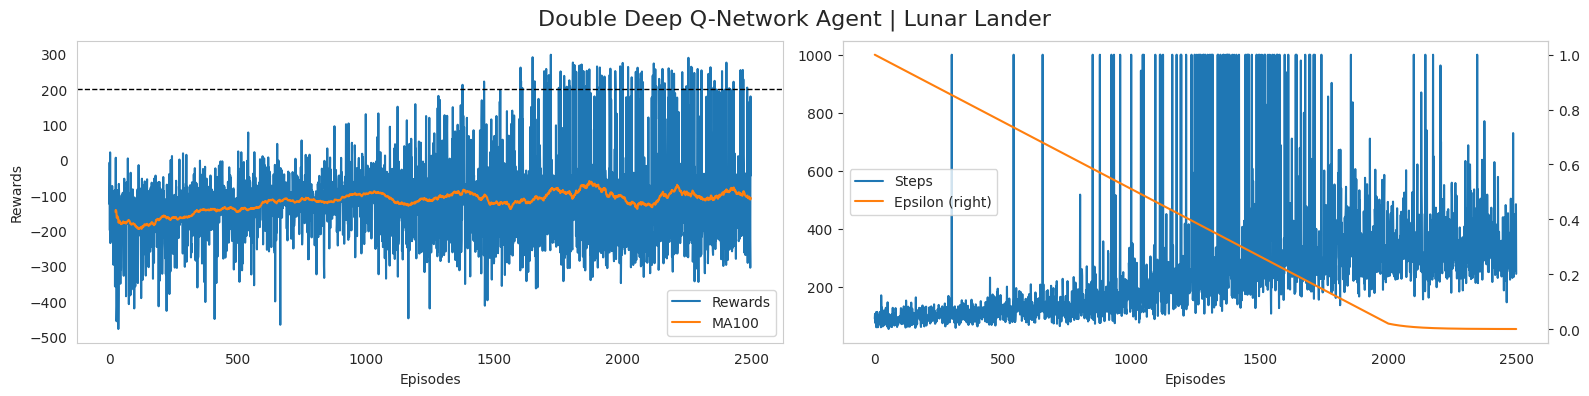

In [28]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 4), sharex=True)
results[["Rewards", "MA100"]].plot(ax=axes[0])
axes[0].set_ylabel("Rewards")
axes[0].set_xlabel("Episodes")
axes[0].axhline(200, c="k", ls="--", lw=1)
results[["Steps", "Epsilon"]].plot(secondary_y="Epsilon", ax=axes[1])
axes[1].set_xlabel("Episodes")
fig.suptitle("Double Deep Q-Network Agent | Lunar Lander", fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.savefig(results_dir / "trading_agent_2ed", dpi=300)

## Tensorboard

In [29]:
%load_ext tensorboard

In [ ]:
%tensorboard --logdir results/lunar_lander/experiment_1

Reusing TensorBoard on port 6006 (pid 630), started 0:01:55 ago. (Use '!kill 630' to kill it.)

<IPython.core.display.Javascript object>